# Step 4 — 慢機台下鑽

**目標**：找出持續性慢的 device（非偶發異常）

**修改下方 PARAMS cell 的參數後，Run All Cells**

In [1]:
# ===== 共用參數 =====
exec(open('../config/params.py').read())
# ==============================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
REPORTS_DIR = Path('../reports')

df = pd.read_csv(DATA_PATH)
df['order_created_at'] = pd.to_datetime(df['order_created_at'], format=DATETIME_FORMAT)
sys_flags = pd.read_csv('../data/system_anomaly_flags.csv')
usr_flags = pd.read_csv('../data/user_anomaly_flags.csv')
df = df.merge(sys_flags, on='order_id').merge(usr_flags, on='order_id')

normal = df[~(df['is_system_anomaly'] | df['is_user_anomaly'])].copy()
print(f"Normal orders: {len(normal):,}")


Normal orders: 29,158


## Device Ranking + Gap Detection

In [3]:
device_perf = normal.groupby('device_id').agg(
    device_dur_median=('device_duration_avg_seconds', 'median'),
    device_dur_mean=('device_duration_avg_seconds', 'mean'),
    device_dur_p95=('device_duration_avg_seconds', lambda x: x.quantile(0.95)),
    order_count=('order_id', 'count'),
).reset_index()

loc_info = df.groupby('device_id').agg(
    loc_1=('loc_1', 'first'), loc_2=('loc_2', 'first'),
    system_name=('system_name', 'first'), device_mode_name=('device_mode_name', 'first'),
).reset_index()
device_perf = device_perf.merge(loc_info, on='device_id')

# Gap detection
sorted_perf = device_perf.sort_values('device_dur_median', ascending=False).reset_index(drop=True)

if len(sorted_perf) < 2:
    print("⚠️  不足 2 台 device，無法做 gap detection")
    slow_devices = pd.DataFrame()
    method = "skipped (< 2 devices)"
    n_slow = 0
    slow_ids = set()
else:
    sorted_perf['gap_to_next'] = sorted_perf['device_dur_median'].diff(-1).abs()
    max_gap_idx = sorted_perf['gap_to_next'].idxmax()
    gap_value = sorted_perf.loc[max_gap_idx, 'gap_to_next']
    next_value = sorted_perf.loc[max_gap_idx + 1, 'device_dur_median'] if max_gap_idx + 1 < len(sorted_perf) else 0
    gap_ratio = gap_value / next_value if next_value > 0 else float('inf')

    if gap_ratio >= GAP_MIN_RATIO:
        slow_devices = sorted_perf.loc[:max_gap_idx]
        method = f"gap detection (gap={gap_value:.1f}s, ratio={gap_ratio:.1f}x)"
    else:
        global_median = device_perf['device_dur_median'].median()
        slow_devices = device_perf[device_perf['device_dur_median'] > 2 * global_median]
        method = f"fallback: > 2× global median ({2*global_median:.1f}s)"

n_slow = len(slow_devices)
slow_ids = set(slow_devices['device_id'])

print(f"Method: {method}")
print(f"Slow devices: {n_slow}")
if n_slow > 0:
    print(f"\n{slow_devices[['device_id','device_dur_median','device_dur_p95','order_count','loc_1','system_name']].to_string(index=False)}")
else:
    print("\nℹ️  沒有明顯的慢機台，所有 device 效能差異不大")


Method: gap detection (gap=10.0s, ratio=3.3x)
Slow devices: 8

device_id  device_dur_median  device_dur_p95  order_count loc_1 system_name
 DEV-0189               14.0            20.0          148 FAB-C   SYS-ALPHA
 DEV-0006               13.5            21.0          144 FAB-A    SYS-BETA
 DEV-0057               13.0            21.0          151 FAB-C   SYS-ALPHA
 DEV-0062               13.0            21.0          147 FAB-C   SYS-ALPHA
 DEV-0163               13.0            20.0          168 FAB-B   SYS-GAMMA
 DEV-0028               13.0            21.0          135 FAB-A   SYS-ALPHA
 DEV-0035               13.0            21.0          150 FAB-B   SYS-GAMMA
 DEV-0070               13.0            22.0          124 FAB-A    SYS-BETA


## 圖表

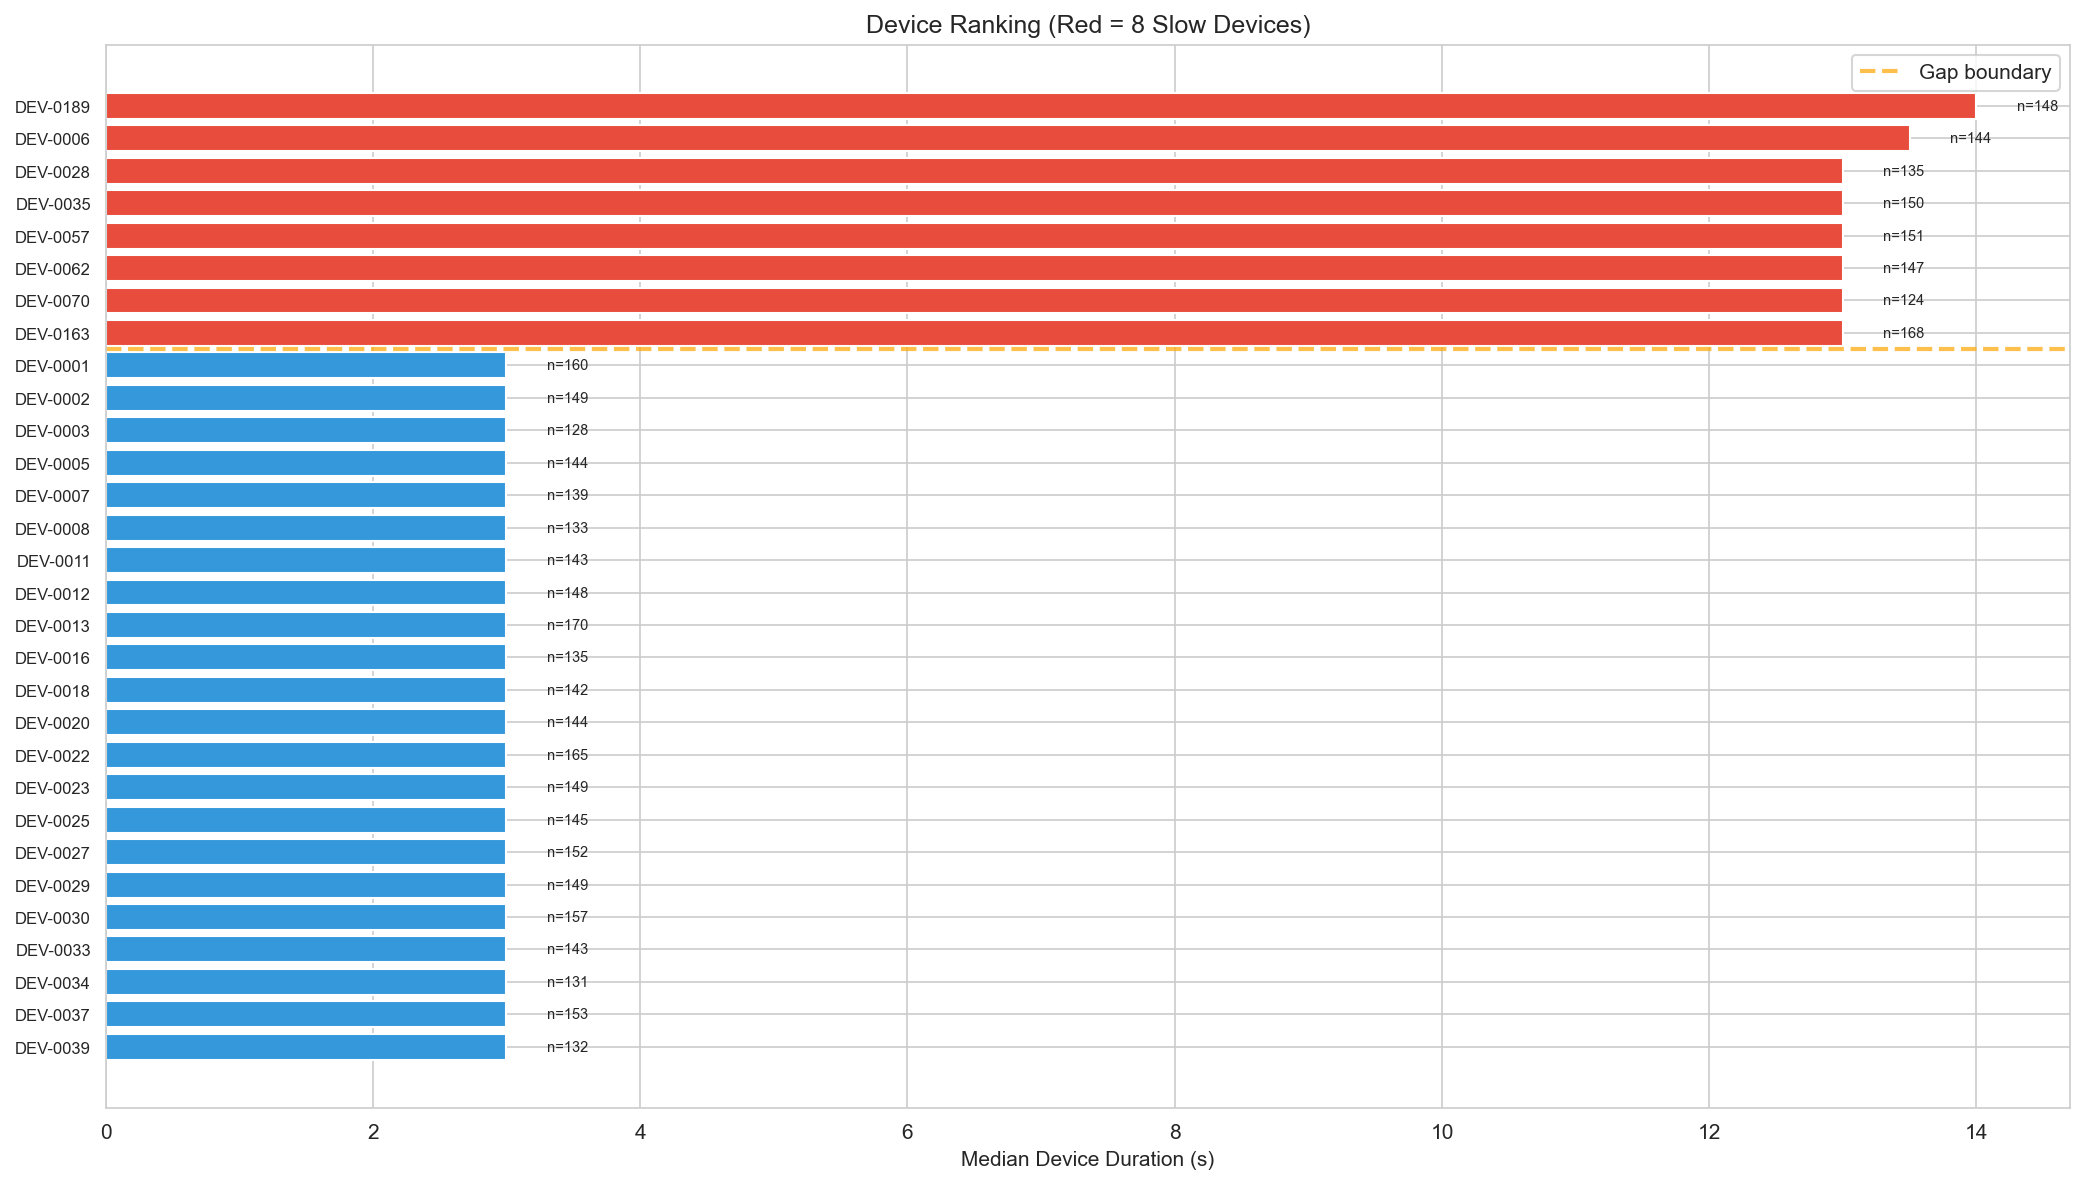

In [4]:
# Device ranking chart
top30 = device_perf.nlargest(30, 'device_dur_median')

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#e74c3c' if d in slow_ids else '#3498db' for d in top30['device_id']]
ax.barh(range(len(top30)), top30['device_dur_median'].values, color=colors)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30['device_id'].values, fontsize=8)
ax.set_title(f'Device Ranking (Red = {n_slow} Slow Devices)')
ax.set_xlabel('Median Device Duration (s)')
ax.invert_yaxis()
if n_slow > 0 and n_slow < 30:
    ax.axhline(y=n_slow - 0.5, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Gap boundary')
    ax.legend()
for i, (dur, cnt) in enumerate(zip(top30['device_dur_median'], top30['order_count'])):
    ax.text(dur + 0.3, i, f'n={cnt}', va='center', fontsize=7)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step4_device_ranking.png', dpi=150)
plt.show()


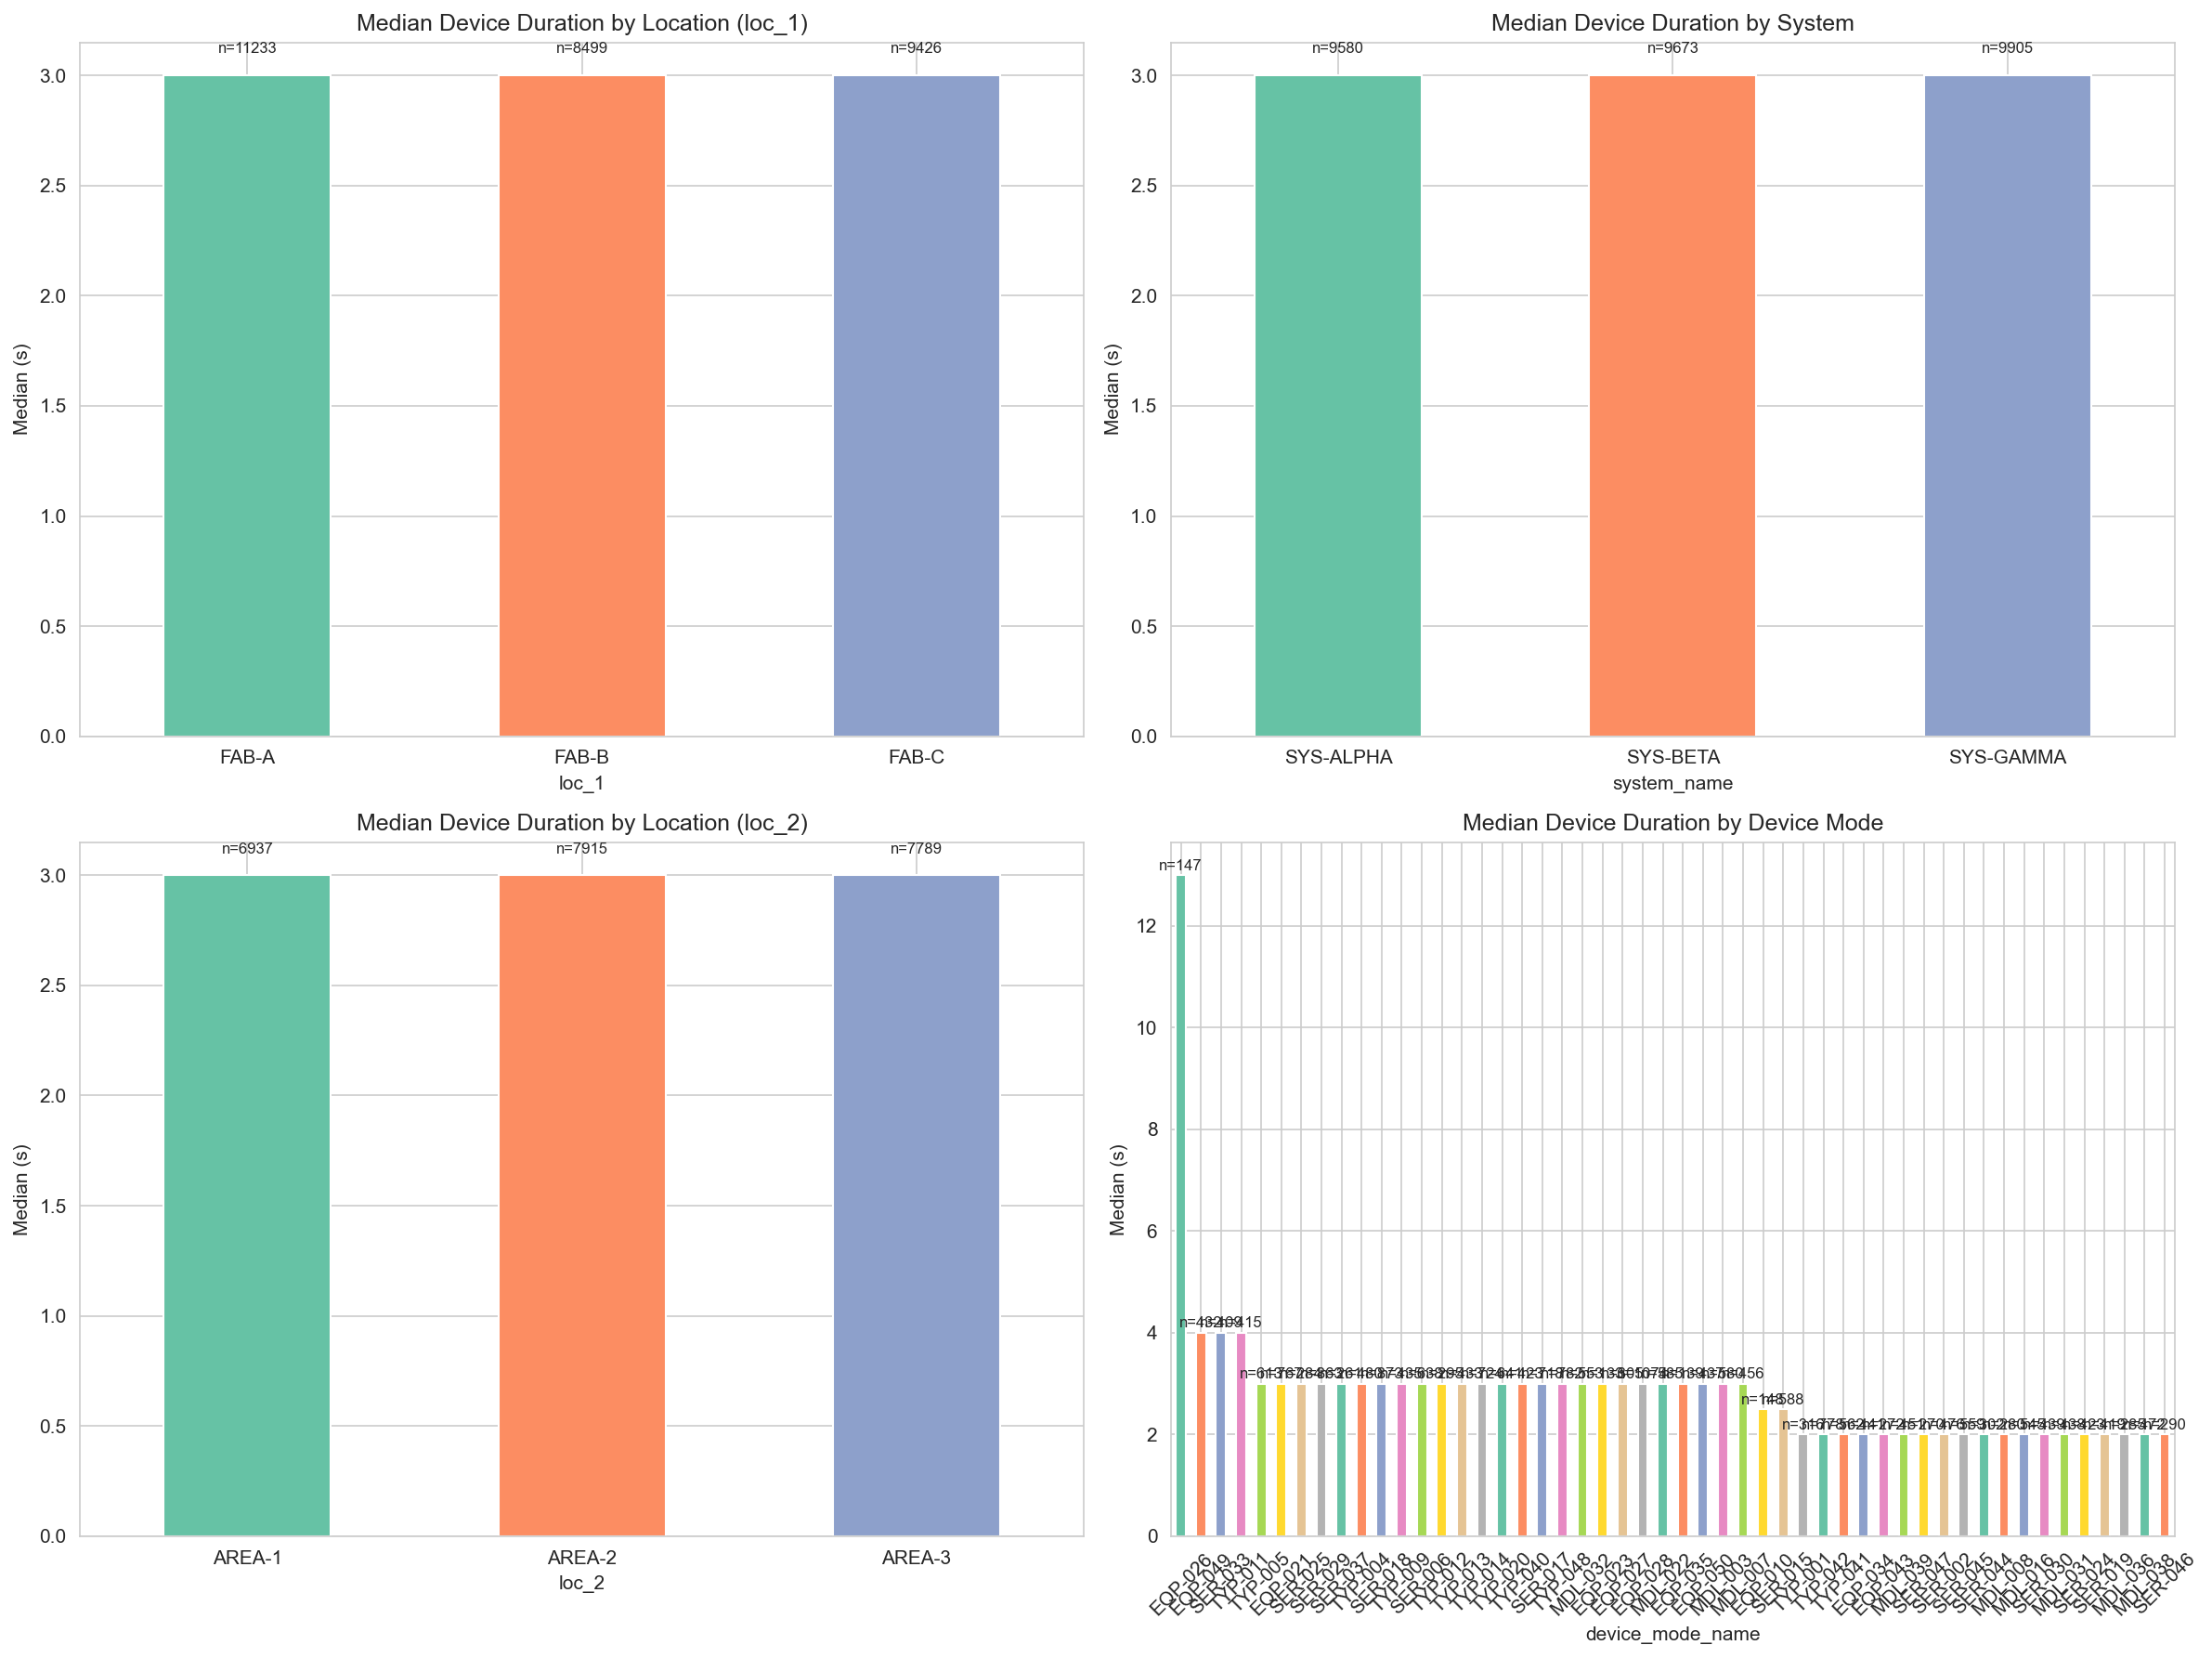

✓ loc_1 無顯著差異 (max/min=1.0x)
✓ system_name 無顯著差異 (max/min=1.0x)


In [5]:
# Facet analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, (col, title) in zip(axes.flat, [
    ('loc_1', 'Location (loc_1)'), ('system_name', 'System'),
    ('loc_2', 'Location (loc_2)'), ('device_mode_name', 'Device Mode'),
]):
    data = normal.dropna(subset=[col]) if col in ['loc_2', 'device_mode_name'] else normal
    stats = data.groupby(col)['device_duration_avg_seconds'].agg(['median','count']).sort_values('median', ascending=False)
    stats['median'].plot(kind='bar', ax=ax, color=sns.color_palette('Set2'))
    ax.set_title(f'Median Device Duration by {title}')
    ax.set_ylabel('Median (s)')
    ax.tick_params(axis='x', rotation=0 if len(stats) < 6 else 45)
    for i, (idx, row) in enumerate(stats.iterrows()):
        ax.text(i, row['median'] + 0.1, f'n={int(row["count"])}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step4_facet_analysis.png', dpi=150)
plt.show()

# Data-driven facet conclusion
for facet in ['loc_1', 'system_name']:
    stats = normal.groupby(facet)['device_duration_avg_seconds'].median()
    ratio = stats.max() / stats.min() if stats.min() > 0 else float('inf')
    if ratio > 1.5:
        print(f"⚠️  {facet} 有顯著差異 (max/min={ratio:.1f}x)")
    else:
        print(f"✓ {facet} 無顯著差異 (max/min={ratio:.1f}x)")


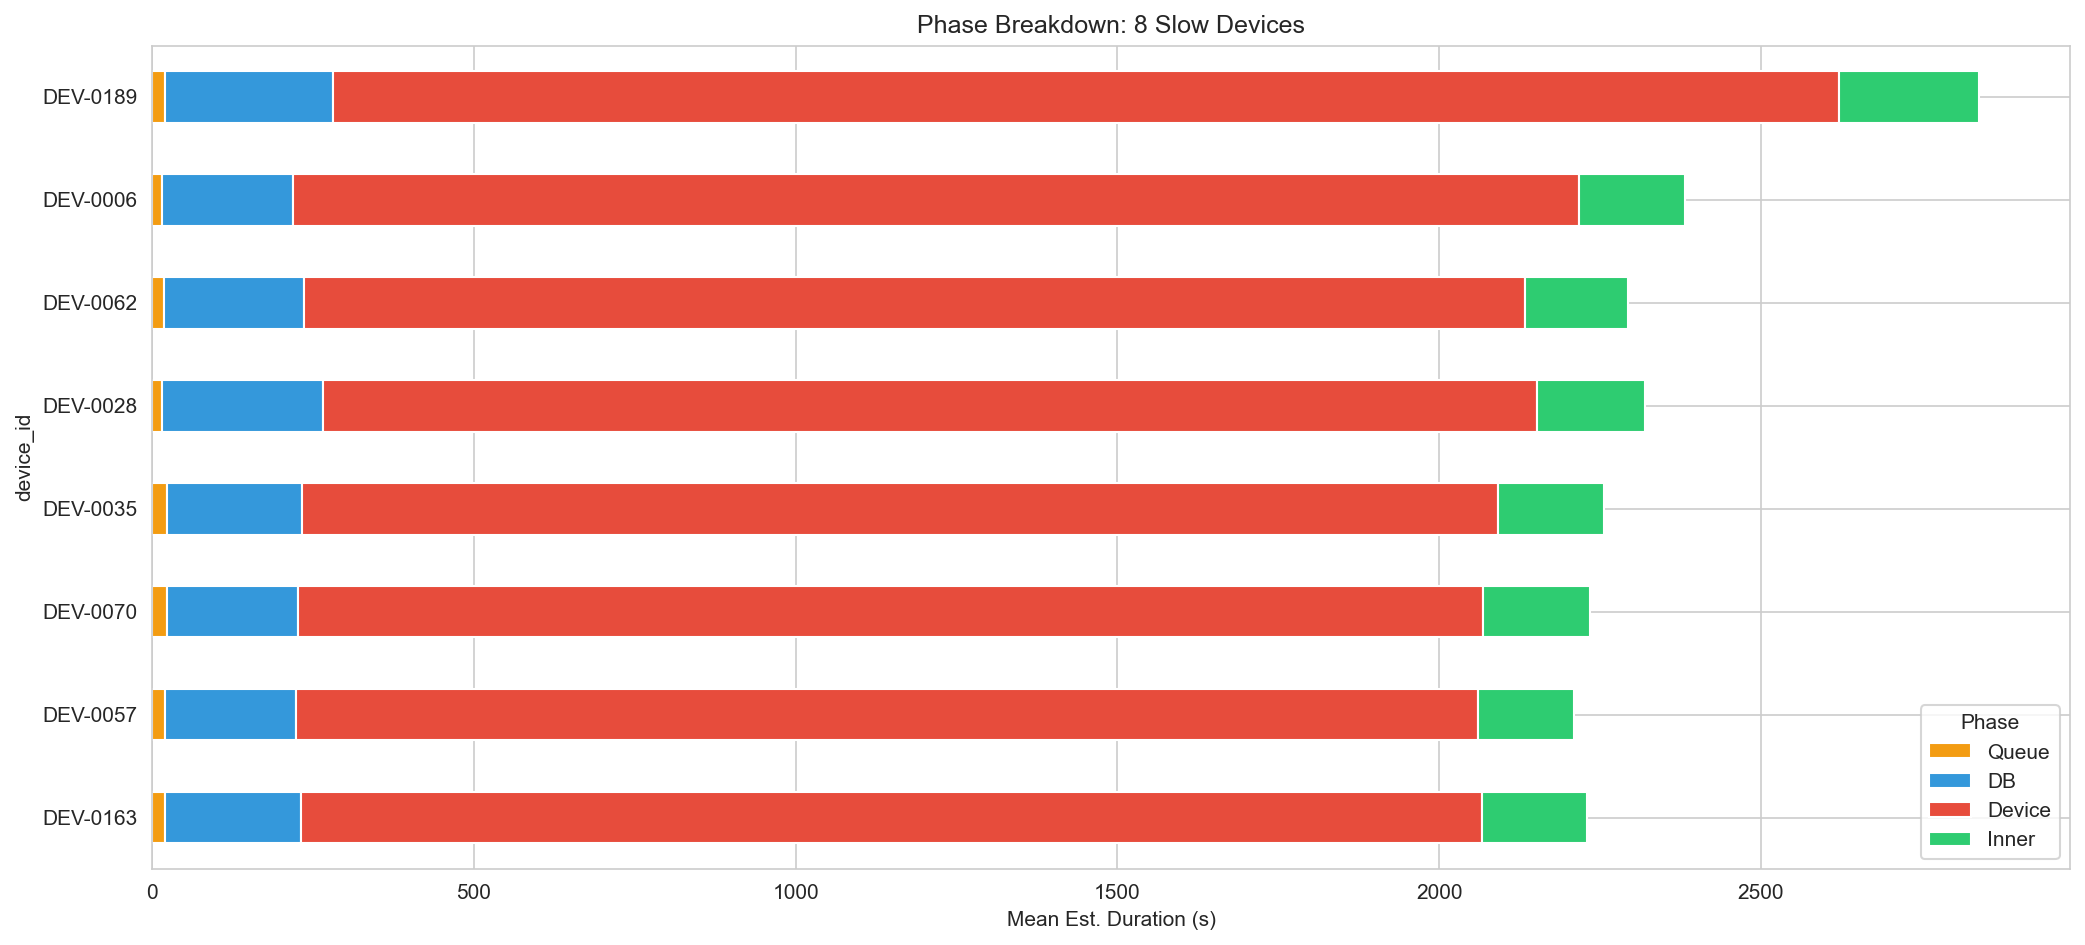

In [6]:
# Slow device phase breakdown (if any)
if n_slow > 0:
    slow_orders = normal[normal['device_id'].isin(slow_ids)].copy()
    slow_orders['est_device'] = slow_orders['device_duration_avg_seconds'] * slow_orders['file_count'] / PARALLELISM
    slow_orders['est_db'] = slow_orders['db_duration_avg_seconds'] * slow_orders['file_count'] / PARALLELISM
    slow_orders['est_inner'] = slow_orders['inner_processing_duration_avg_seconds'] * slow_orders['file_count'] / PARALLELISM
    slow_orders['est_queue'] = slow_orders['queue_duration_seconds']

    fig, ax = plt.subplots(figsize=(14, max(4, n_slow * 0.8)))
    phase_by_dev = slow_orders.groupby('device_id')[['est_queue','est_db','est_device','est_inner']].mean()
    phase_by_dev.columns = ['Queue', 'DB', 'Device', 'Inner']
    phase_by_dev.sort_values('Device', ascending=True).plot(
        kind='barh', stacked=True, ax=ax, color=['#f39c12','#3498db','#e74c3c','#2ecc71'])
    ax.set_title(f'Phase Breakdown: {n_slow} Slow Devices')
    ax.set_xlabel('Mean Est. Duration (s)')
    ax.legend(title='Phase')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'step4_slow_device_breakdown.png', dpi=150)
    plt.show()


## Summary

In [7]:
print(f"=== Step 4 Summary ===")
print(f"Method: {method}")
print(f"Slow devices: {n_slow}")
if n_slow > 0:
    for _, row in slow_devices.iterrows():
        print(f"  {row['device_id']}: median={row['device_dur_median']:.1f}s, "
              f"p95={row['device_dur_p95']:.1f}s, n={row['order_count']}, "
              f"loc={row['loc_1']}/{row.get('loc_2','')}, sys={row['system_name']}")


=== Step 4 Summary ===
Method: gap detection (gap=10.0s, ratio=3.3x)
Slow devices: 8
  DEV-0189: median=14.0s, p95=20.0s, n=148, loc=FAB-C/AREA-3, sys=SYS-ALPHA
  DEV-0006: median=13.5s, p95=21.0s, n=144, loc=FAB-A/AREA-2, sys=SYS-BETA
  DEV-0057: median=13.0s, p95=21.0s, n=151, loc=FAB-C/None, sys=SYS-ALPHA
  DEV-0062: median=13.0s, p95=21.0s, n=147, loc=FAB-C/AREA-3, sys=SYS-ALPHA
  DEV-0163: median=13.0s, p95=20.0s, n=168, loc=FAB-B/None, sys=SYS-GAMMA
  DEV-0028: median=13.0s, p95=21.0s, n=135, loc=FAB-A/AREA-1, sys=SYS-ALPHA
  DEV-0035: median=13.0s, p95=21.0s, n=150, loc=FAB-B/AREA-1, sys=SYS-GAMMA
  DEV-0070: median=13.0s, p95=22.0s, n=124, loc=FAB-A/AREA-2, sys=SYS-BETA


In [8]:
# Export summary to reports/
summary = []
summary.append("=" * 60)
summary.append("Step 4 — Slow Device Drilldown")
summary.append("=" * 60)
summary.append(f"\nMethod: {method}")
summary.append(f"Slow devices: {n_slow}")
if n_slow > 0:
    summary.append(f"\nSlow Device List:")
    for _, row in slow_devices.iterrows():
        summary.append(f"  {row['device_id']}: median={row['device_dur_median']:.1f}s, "
              f"p95={row['device_dur_p95']:.1f}s, n={row['order_count']}, "
              f"loc={row['loc_1']}/{row.get('loc_2','')}, sys={row['system_name']}")

with open(str(REPORTS_DIR / 'step4_summary.txt'), 'w') as f:
    f.write('\n'.join(summary))
print(f"Saved: reports/step4_summary.txt")

Saved: reports/step4_summary.txt
